<a href="https://colab.research.google.com/github/saiprasanthreddy/ml-things/blob/main/prophet_time_series_Forecasting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install pystan
!pip install prophet

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prophet
%matplotlib inline

In [11]:
dataset = pd.read_csv('/content/airline_passengers.csv')

dataset

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0
...,...,...
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


<Axes: >

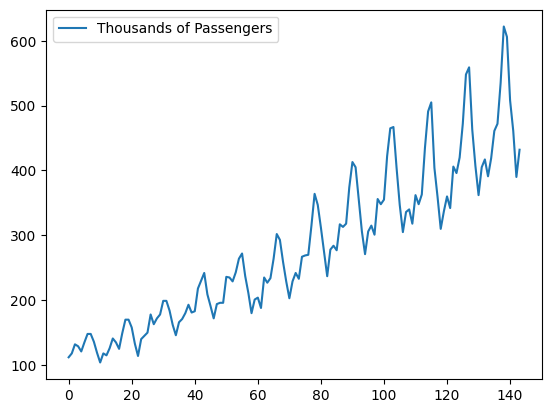

In [12]:
dataset.plot()

In [15]:
dataset.columns=['ds','y']

dataset.head()

,ds,y
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [16]:
dataset.drop(144,axis=0,inplace=True)

In [17]:
dataset.tail()

,ds,y
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [18]:
dataset['ds'] = pd.to_datetime(dataset['ds'])

In [19]:
dataset.head()

,ds,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [21]:
dataset.dtypes

,0
ds,datetime64[ns]
y,float64


In [22]:
from prophet import Prophet

In [23]:
dir(prophet)

['Path',
 'Prophet',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'about',
 'diagnostics',
 'f',
 'forecaster',
 'here',
 'make_holidays',
 'models',
 'plot']

In [25]:
model = Prophet()

In [26]:
dataset.columns

Index(['ds', 'y'], dtype='object')

In [28]:
dataset.dropna(axis = 0  ,inplace=True)

In [29]:
model.fit(dataset)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [32]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [33]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)


In [34]:
future_dates.tail()

,ds
504,1961-11-27
505,1961-11-28
506,1961-11-29
507,1961-11-30
508,1961-12-01


In [35]:
prediction=model.predict(future_dates)


In [36]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.406531,55.670558,113.729474,107.406531,107.406531,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,0.0,0.0,0.0,86.019134
1,1949-02-01,109.550753,51.243446,108.430028,109.550753,109.550753,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,0.0,0.0,0.0,79.495466
2,1949-03-01,111.487469,82.287051,139.344891,111.487469,111.487469,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,0.0,0.0,0.0,111.025724
3,1949-04-01,113.631691,79.582525,136.567155,113.631691,113.631691,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,0.0,0.0,0.0,108.719164
4,1949-05-01,115.706744,83.175876,140.610535,115.706744,115.706744,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,0.0,0.0,0.0,112.095464


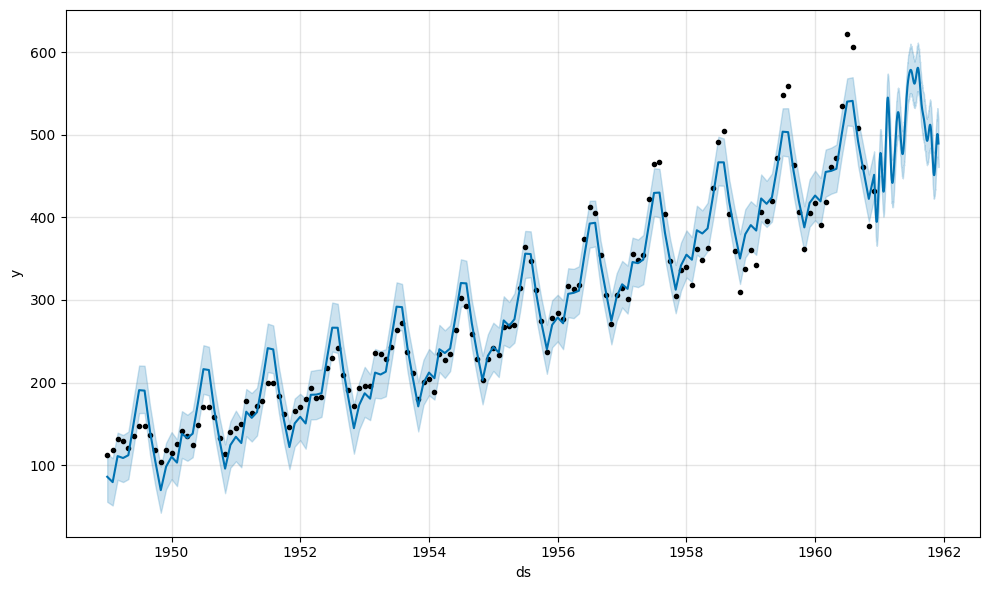

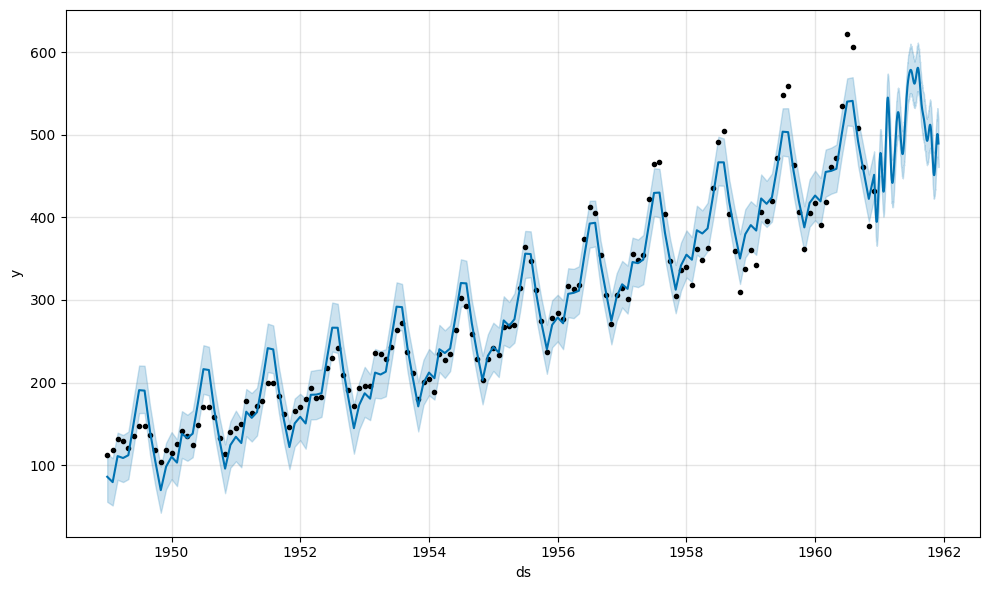

In [38]:
model.plot(prediction)

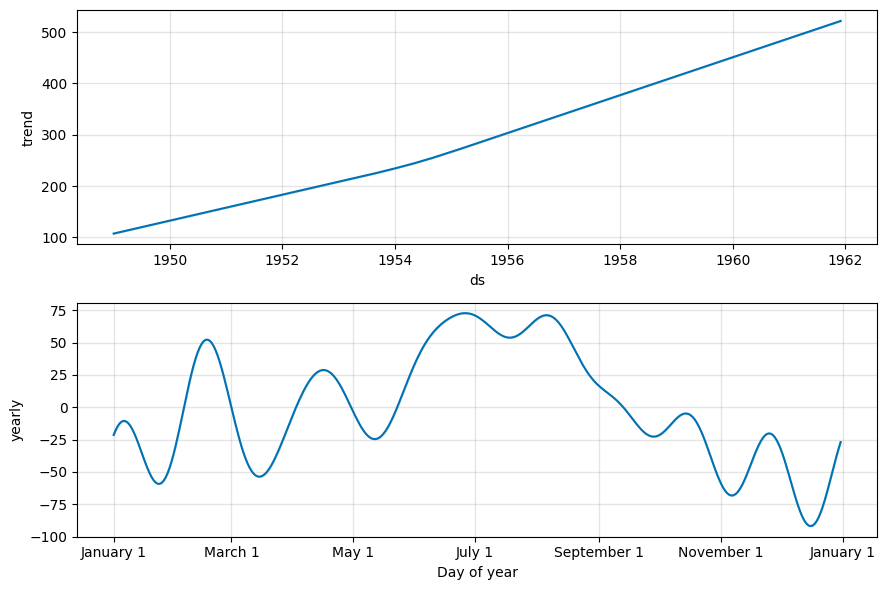

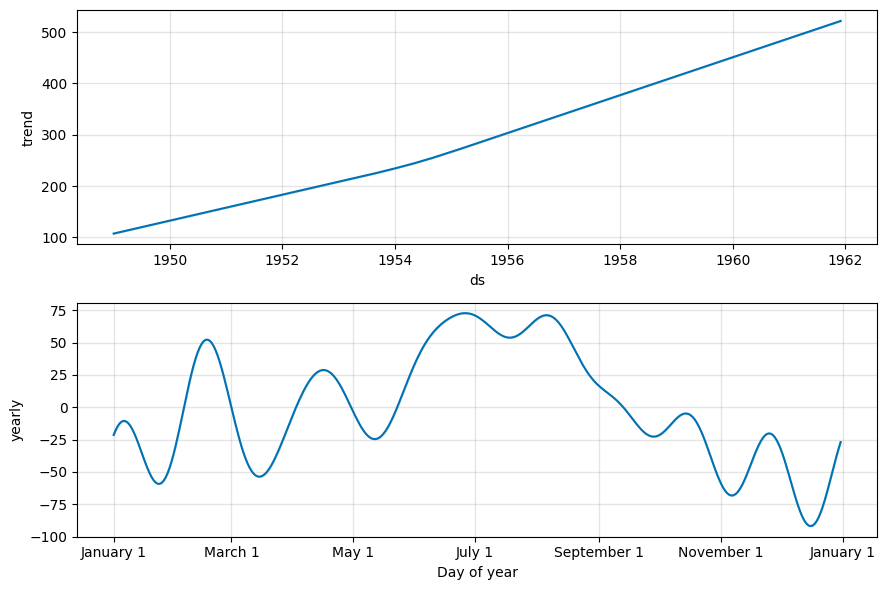

In [39]:
model.plot_components(prediction)

In [41]:
# Time Series Analysis

# 1960-1962
# Cross Validation
# 1960-61---Train dataset
# 1961-62--Test dataset
# 1962-63---Validation

In [43]:
dataset.head()

,ds,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [44]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')

INFO:prophet:Making 19 forecasts with cutoffs between 1951-01-18 00:00:00 and 1959-12-02 00:00:00


  0%|          | 0/19 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [46]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,158.547167,158.304812,158.811303,150.0,1951-01-18
1,1951-03-01,171.930526,171.170428,172.743416,178.0,1951-01-18
2,1951-04-01,160.294098,158.766015,161.834473,163.0,1951-01-18
3,1951-05-01,146.088907,143.745890,148.569401,172.0,1951-01-18
4,1951-06-01,181.775447,178.492752,185.178736,178.0,1951-01-18


In [47]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)

In [48]:
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1089.756319,33.011457,25.888132,0.078584,0.073831,0.079624,0.227273
1,42 days,1015.069514,31.860156,25.207098,0.076726,0.073831,0.077409,0.181818
2,46 days,909.811604,30.163083,24.621984,0.078579,0.078887,0.078319,0.136364
3,47 days,1044.412302,32.317368,26.737303,0.081350,0.085408,0.081498,0.136364
4,48 days,1034.021370,32.156203,26.194391,0.079480,0.085408,0.079693,0.181818
...,...,...,...,...,...,...,...,...
165,359 days,766.596882,27.687486,21.654229,0.068947,0.062001,0.068551,0.250000
166,360 days,770.120029,27.751037,21.933109,0.069808,0.062001,0.069431,0.227273
167,362 days,864.686398,29.405550,23.203340,0.068900,0.062001,0.069029,0.227273
168,364 days,838.269176,28.952879,22.134206,0.065983,0.050250,0.066210,0.272727


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


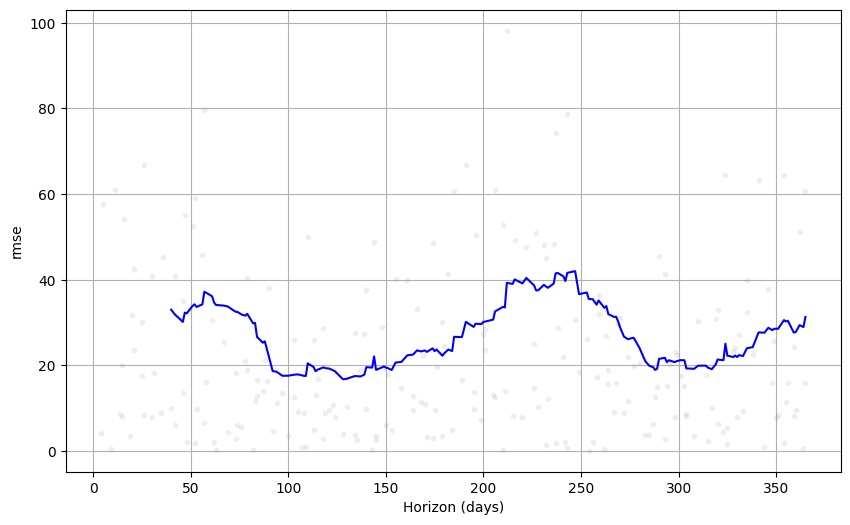

In [50]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')